# Objective:
To graph the two first figures of the assignement showing all raw data, and give information about each record.

In [2]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import os

# %matplotlib widget

In [111]:
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

# Load recording data
fNamerecord = 'data/001MoDe_R1.csv'
record = np.genfromtxt(fNamerecord, delimiter=',', skip_header=3, skip_footer=2, names=True)
record_info = np.genfromtxt(fNamerecord, delimiter=';', skip_footer=19597, names=True)

# Load markers and results data
fNameresults = 'data/001MoDe_R1.marker.csv'
markers = np.genfromtxt(fNameresults, dtype=(str,float,'U100'), delimiter=',', skip_header=3, skip_footer=9, usecols=(1,2))  # Load marker as int, rest as str and without date-time
results = np.genfromtxt(fNameresults, dtype=str, delimiter=',', skip_header=17, skip_footer=1)

# Show recording information
print(f"Header line information in 'data/001MoDe_R1.csv':\n{chr(10).join([name.replace('_', ': ') for name in record_info.dtype.names])}")

# As well as markers and performance information
formatted_markers = [f"{marker[0]}: {marker[1]}" for marker in markers]  # Display ": " between name and value, possible because markers are 2 cols of str
print(f"\nMarkers in 'data/001MoDe_R1.marker.csv':\n{chr(10).join(formatted_markers)}")
for row in results:
    print(' '.join(row))

# Calculate and print record times
durations = []
for i in range(3, 12):
    duration = (markers[i][0] - markers[i-1][0]) / 1000  # Convert to seconds
    durations.append(duration)
durations = np.array(durations)

print(durations)

# Print only record durations (elements 0, 2, 4, ...)
print("\nrecord times (milliseconds since the Unix epoch, 00:00:00 UTC on January 1, 1970):")
for i in range(0, len(durations), 2):  # Step by 2 to get elements 0, 2, 4, ...
    marker_start = markers[i+3-1][0]  # Previous marker timestamp
    marker_end = markers[i+3][0]      # Current marker timestamp
    duration_s = durations[i]  # Duration in seconds
    print(f"{marker_start:.0f} to {marker_end:.0f} ({duration_s:.3f} s)")

# Print record times relative to first DoRecord marker
print("\nrecord times (seconds since the first DoRecord marker):")
first_dorecord = markers[2][0] / 1000  # Convert first DoRecord marker to seconds
for i in range(0, len(durations), 2):  # Step by 2 to get elements 0, 2, 4, ...
    marker_start_rel = (markers[i+3-1][0] / 1000) - first_dorecord + 0.004  # Previous marker relative time
    marker_end_rel = (markers[i+3][0] / 1000) - first_dorecord + 0.004      # Current marker relative time
    duration_s = durations[i]  # Duration in seconds
    print(f"{marker_start_rel:7.3f} to {marker_end_rel:7.3f} ({duration_s:.3f} s)")

# Thresholds between records: all values equal 0
threshold_indices = np.where(record['timestamp'] == 0)[0]
print(f"\nTimestamps equal to 0 found at indices: {threshold_indices}")  # Threshold indices output for later use

Header line information in 'data/001MoDe_R1.csv':
screenWidth: 1104
screenHeight: 661
cornerX: 302
cornerY: 80
centerX: 552
centerY: 330
externalRadius: 250
internalRadius: 170
borderRadius: 1
cursorRadius: 16
indexOfDifficulty: 2800696429476858
taskRadius: 2095
taskTolerance: 47
borderColor: javaawtColorr255g255b255
backgroundColor: javaawtColorr0g0b0
cursorColorRecord: javaawtColorr255g0b0
cursorColorWait: javaawtColorr255g255b0
autoStart: 3600
cycleMaxNumber: 6
cycleDuration: 20
software: LSLmouse
version: 120rc5
task: CircularTarget
isWithLSL: false

Markers in 'data/001MoDe_R1.marker.csv':
1616776712325.0: KeyTyped=32 DoCycleChange
1616776712331.0: DoCycleChange:DoStartCycleTimedSequence
1616776712333.0: DoCycleChange:DoRecord RecordDone=0 PauseDone=0 ToDo=6
1616776732336.0: DoCycleChange:DoPause RecordDone=1 PauseDone=0 ToDo=6
1616776752340.0: DoCycleChange:DoRecord RecordDone=1 PauseDone=1 ToDo=6
1616776772351.0: DoCycleChange:DoPause RecordDone=2 PauseDone=1 ToDo=6
161677679237

In [109]:
# Define center
center = np.array([552, 330])

# Extract variables
time = (record['timestamp'][:threshold_indices[0]] - record['timestamp'][0])/1000  # in seconds
x_1 = record['mouseX'][:threshold_indices[0]] - center[0]
y_1 = record['mouseY'][:threshold_indices[0]] - center[1]
tar = record['mouseInTarget'][:threshold_indices[0]]

x_1

array([-51., -65., -68., ..., 148., 145., 142.])

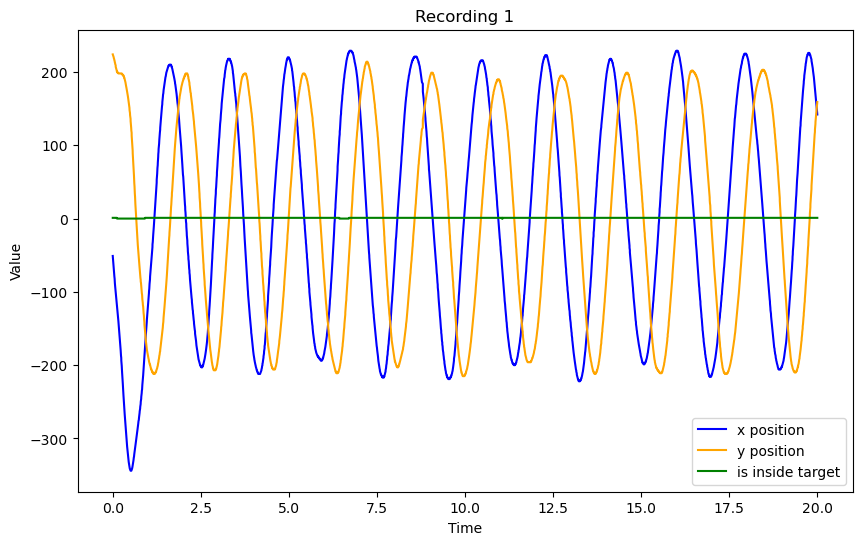

In [110]:
# Plot all data according to time in one plot
plt.figure(figsize=(10, 6))
plt.plot(time, x_1, label='x position', color='blue')
plt.plot(time, y_1, label='y position', color='orange')
plt.plot(time, tar, label='is inside target', color='green')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Recording 1')
plt.legend()
plt.show()